# Анализ данных

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

train = pd.read_csv("train.csv")
test = pd.read_csv("test.csv")
train["Title"] = train["Name"].str.split(",").str[1].str.split(".").str[0].str.strip()
test["Title"] = test["Name"].str.split(",").str[1].str.split(".").str[0].str.strip()
display(train.head(20))
print("-" * 150)
display(test.head(10))

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Title
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S,Mr
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,Mrs
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,Miss
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S,Mrs
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S,Mr
5,6,0,3,"Moran, Mr. James",male,NaN,0,0,330877,8.4583,NaN,Q,Mr
6,7,0,1,"McCarthy, Mr. Timothy J",male,54.0,0,0,17463,51.8625,E46,S,Mr
7,8,0,3,"Palsson, Master. Gosta Leonard",male,2.0,3,1,349909,21.0750,NaN,S,Master
8,9,1,3,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",female,27.0,0,2,347742,11.1333,NaN,S,Mrs
9,10,1,2,"Nasser, Mrs. Nicholas (Adele Achem)",female,14.0,1,0,237736,30.0708,NaN,C,Mrs


------------------------------------------------------------------------------------------------------------------------------------------------------


,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Title
0,892,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q,Mr
1,893,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S,Mrs
2,894,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q,Mr
3,895,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S,Mr
4,896,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S,Mrs
5,897,3,"Svensson, Mr. Johan Cervin",male,14.0,0,0,7538,9.2250,NaN,S,Mr
6,898,3,"Connolly, Miss. Kate",female,30.0,0,0,330972,7.6292,NaN,Q,Miss
7,899,2,"Caldwell, Mr. Albert Francis",male,26.0,1,1,248738,29.0000,NaN,S,Mr
8,900,3,"Abrahim, Mrs. Joseph (Sophie Halaut Easu)",female,18.0,0,0,2657,7.2292,NaN,C,Mrs
9,901,3,"Davies, Mr. John Samuel",male,21.0,2,0,A/4 48871,24.1500,NaN,S,Mr


## 1. Задача проекта

**Цель работы:** Анализ и обработка данных для создания модели, предсказывающей выживет человек в крушении Титаника или нет

**Тип задачи:** Классификация

## 2. Описание датасетов

In [3]:
train.info()
print("-" * 100)
test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 13 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
 12  Title        891 non-null    object 
dtypes: float64(2), int64(5), object(6)
memory usage: 90.6+ KB
----------------------------------------------------------------------------------------------------
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 12 column

**Тематика:** Данные пасажиров, находившихся на Титанике

**Источник:** Kaggle

**Количество записей:** Датасет train - 891, датасет test - 418

**Количество признаков:** Датасет train - 11 + 1 целевой признак `Survived`, датасет test - 11

**Целевая переменная:** `Survived`

## 3. Описание признаков

# Признаки датасетов

## Категориальные

`Pclass` - Класс каюты пассажира

`Cabin` - Номер каюты

`Name` - Имя пассажира

`Sex` - Пол пассажира

`Ticket` - Номера билета

`Embarked` - Порт посадки

`Title` - Титул пассажира

`Survived` - Выжил пассажир или нет (целевой признак, есть только в train)

## Количественные признаки

`Age` - Возраст пассажира

`Fare` - Стоимость билета

`Parch` - Кол-во родителей/детей, отправившихся в поездку

`SibSp` - Кол-во братьев/сестер/супругов, находящихся в поездке

## 4. Пропуски

In [4]:
missing_train_data = train.isna().sum()
missing_test_data = test.isna().sum()
display(missing_train_data)
print("-" * 100)
display(missing_test_data)

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


----------------------------------------------------------------------------------------------------


,0
PassengerId,0
Pclass,0
Name,0
Sex,0
Age,86
SibSp,0
Parch,0
Ticket,0
Fare,1
Cabin,327


## 5. Статистики

## Статистики количественных признаков

In [5]:
display(train.drop(["Survived", "Pclass"], axis=1).describe())
print("-" * 100)
display(test.drop("Pclass", axis=1).describe())

,PassengerId,Age,SibSp,Parch,Fare
count,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,29.699118,0.523008,0.381594,32.204208
std,257.353842,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,38.000000,1.000000,0.000000,31.000000
max,891.000000,80.000000,8.000000,6.000000,512.329200


----------------------------------------------------------------------------------------------------


,PassengerId,Age,SibSp,Parch,Fare
count,418.000000,332.000000,418.000000,418.000000,417.000000
mean,1100.500000,30.272590,0.447368,0.392344,35.627188
std,120.810458,14.181209,0.896760,0.981429,55.907576
min,892.000000,0.170000,0.000000,0.000000,0.000000
25%,996.250000,21.000000,0.000000,0.000000,7.895800
50%,1100.500000,27.000000,0.000000,0.000000,14.454200
75%,1204.750000,39.000000,1.000000,0.000000,31.500000
max,1309.000000,76.000000,8.000000,9.000000,512.329200


## Статистики категориальных признаков

In [6]:
display(train.describe(include="object"))
print("-" * 100)
display(test.describe(include="object"))

,Name,Sex,Ticket,Cabin,Embarked,Title
count,891,891,891,204,889,891
unique,891,2,681,147,3,17
top,"Dooley, Mr. Patrick",male,347082,G6,S,Mr
freq,1,577,7,4,644,517


----------------------------------------------------------------------------------------------------


,Name,Sex,Ticket,Cabin,Embarked,Title
count,418,418,418,91,418,418
unique,418,2,363,76,3,9
top,"Peter, Master. Michael J",male,PC 17608,B57 B59 B63 B66,S,Mr
freq,1,266,5,3,270,240


## Статистики Pclass

In [7]:
print("Класс каюты пассажира (train)")
print(f"Самое частое значение: {train['Pclass'].mode()[0]}")
print(f"Кол-во кают первого класса: {len(train[train['Pclass'] == 1])}")
print(f"Кол-во кают второго класса: {len(train[train['Pclass'] == 2])}")
print(f"Кол-во кают третьего класса: {len(train[train['Pclass'] == 3])}")
print()
print("Класс каюты пассажира (test)")
print(f"Самое частое значение: {test['Pclass'].mode()[0]}")
print(f"Кол-во кают первого класса: {len(test[test['Pclass'] == 1])}")
print(f"Кол-во кают второго класса: {len(test[test['Pclass'] == 2])}")
print(f"Кол-во кают третьего класса: {len(test[test['Pclass'] == 3])}")

Класс каюты пассажира (train)
Самое частое значение: 3
Кол-во кают первого класса: 216
Кол-во кают второго класса: 184
Кол-во кают третьего класса: 491

Класс каюты пассажира (test)
Самое частое значение: 3
Кол-во кают первого класса: 107
Кол-во кают второго класса: 93
Кол-во кают третьего класса: 218


## 6. Выводы

1. **Качество данных:** Дубликаты отсутствуют. Но есть пропуски: train: 866 (`Age`: 177, `Cabin`: 687, `Embarked`: 2), test: 414 (`Age`: 86, `Cabin`: 327, `Fare`: 1)
Целевой признак `Survived` записан цифрами (1 - пассажир выжил, 0 - погиб)

2. **Различия по целевому признаку:** Уже можно сделать вывод, что на целевой признак больше всего влияние оказывает пол (женщины выживали значительно чаще мужчин), и люди с более высоким классом каюты также чаще выживали

3. В числовых признаках, а конкретно в возрасте и стоимости билета присутствуют значения сильно отдаленные от медианы, например, возраст 80 или стоимость билета ~500, что может затруднить обученияе модели, в категориальных признаках заметно, что мужчин почти в 2 раза больше женщин, а среди них почти все взрослые

4. **Рекомендации к предобработке:** Необходимо заполнить пропуски (категориальные признаки - модой; количественные - медианой), также рекомендуется закодировать категориальные признаки (например пол: мужчины - 1, женщины - 0) и провести масштабирование числовых признаков в диапазоне от 0 до 1, а также вместо масштабирования лучше использовать стандартизацию (StandardScaler), т.к. в выборках присутствуют выбросы, а алгоритмом будет логистическая регрессиия

## Визуализация данных

## 1. Цель визуализации

**Цель** Визуализировать зависимости целевой переменной от разных признаков, проверить гипотезы и облегчить в будущем обучение модели

**Распределение количественных, категориальных признаков и целевой переменной**

**Построить матрицу корреляции и тепловую карту**

**Сравнить выживших и погибших пассажиров**

## 2. Подготовка данных

### Заполнение пропусков

In [8]:
# Датасет train

train['Cabin'].fillna(train['Cabin'].mode()[0], inplace=True)
train['Embarked'].fillna(train['Embarked'].mode()[0], inplace=True)

# Датасет test

test['Fare'].fillna(test['Fare'].median(), inplace=True)
test['Cabin'].fillna(test['Cabin'].mode()[0], inplace=True)

/tmp/ipykernel_2661/62102812.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  train['Cabin'].fillna(train['Cabin'].mode()[0], inplace=True)
/tmp/ipykernel_2661/62102812.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=Tru

In [9]:
display(train.isna().sum())
print("-" * 100)
display(test.isna().sum())

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


----------------------------------------------------------------------------------------------------


,0
PassengerId,0
Pclass,0
Name,0
Sex,0
Age,86
SibSp,0
Parch,0
Ticket,0
Fare,0
Cabin,0


## Выбор подходящих инструментов

### Для визуализации будут использоваться библиотеки matplotlib и seaborn

1. Количественные признаки - гистограммы

2. Категориальные признаки - столбчатые диаграммы

3. Проверка на наличие выбросов - ящик с усами

4. Корреляция - тепловая карта

5. Распределение целевой переменной - круговая диаграмма

## 4. Построение визуализаций

### Количественные признаки (гистограммы)

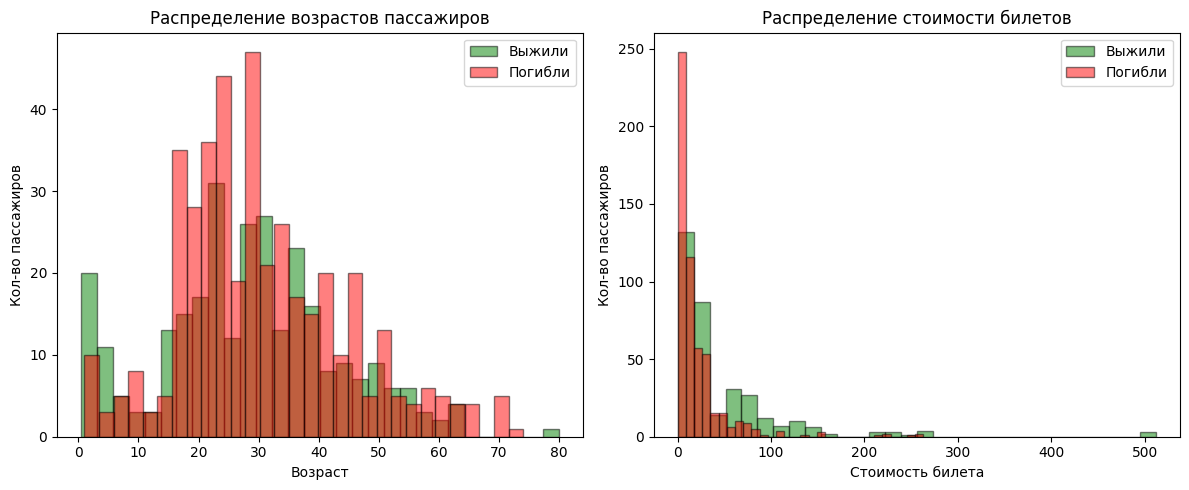

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

survived = train[train['Survived'] == 1]
died = train[train['Survived'] == 0]

axes[0].hist(survived['Age'].dropna(), bins=30, alpha=0.5, label="Выжили", color="green", edgecolor="black")
axes[0].hist(died['Age'].dropna(), bins=30, alpha=0.5, label="Погибли", color="red", edgecolor="black")
axes[0].set_title("Распределение возрастов пассажиров")
axes[0].set_xlabel("Возраст")
axes[0].set_ylabel("Кол-во пассажиров")
axes[0].legend()

axes[1].hist(survived['Fare'].dropna(), bins=30, alpha=0.5, label="Выжили", color="green", edgecolor="black")
axes[1].hist(died['Fare'].dropna(), bins=30, alpha=0.5, label="Погибли", color="red", edgecolor="black")
axes[1].set_title("Распределение стоимости билетов")
axes[1].set_xlabel("Стоимость билета")
axes[1].set_ylabel("Кол-во пассажиров")
axes[1].legend()

plt.tight_layout()
plt.show()

### Категориальные признаки (столбчатые диаграммы)

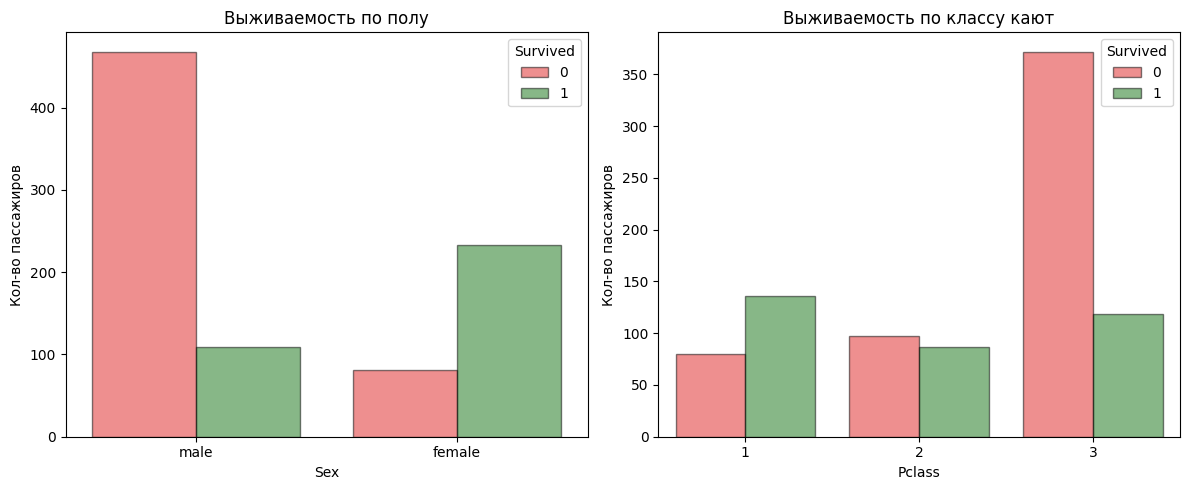

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.countplot(x="Sex", hue="Survived", data=train, ax=axes[0], palette=["red", "green"], alpha=0.5, edgecolor="black")
axes[0].set_title("Выживаемость по полу")
axes[0].set_ylabel("Кол-во пассажиров")

sns.countplot(x="Pclass", hue="Survived", data=train, ax=axes[1], palette=["red", "green"], alpha=0.5, edgecolor="black")
axes[1].set_title("Выживаемость по классу кают")
axes[1].set_ylabel("Кол-во пассажиров")

plt.tight_layout()
plt.show()

### Тепловая карта

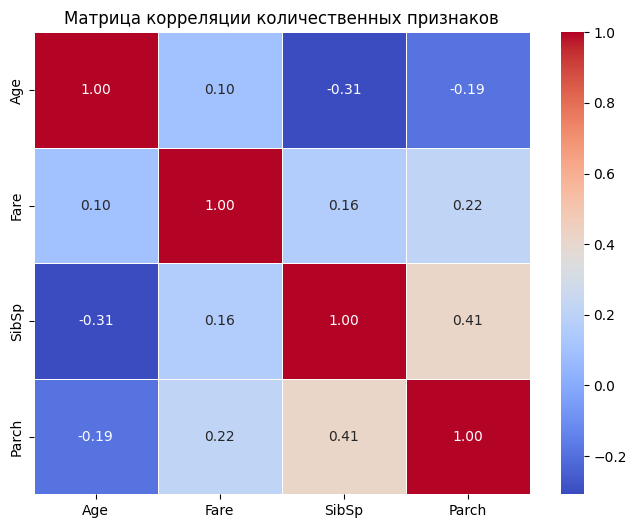

In [12]:
plt.figure(figsize=(8, 6))

numeric_cols = ['Age', 'Fare', 'SibSp', 'Parch']

sns.heatmap(train[numeric_cols].corr(), annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)

plt.title("Матрица корреляции количественных признаков")
plt.show()

### Распределение целевой переменной

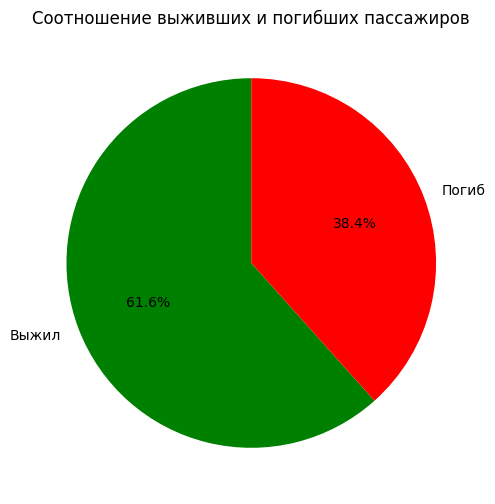

In [13]:
target_counts = train['Survived'].value_counts()

plt.figure(figsize=(6, 6))
plt.pie(target_counts, labels=["Выжил", "Погиб"], autopct="%1.1f%%", startangle=90, colors=["green", "red"])
plt.title("Соотношение выживших и погибших пассажиров")
plt.show()

## 5. Выводы

**Наличие дисбаланса классов:** Дисбаланс классов отсутствует, модели хватает данных для обучения

**Форма графиков и закономерности:** Как главная закономерность в глаза сразу бросается выживаемость по полу - женщины выживали гораздо чаще мужчин, остальные графики также стабильные, видны зависимости от класса каюты, а также что погибло очень много мужчин в возрасте 25-35 лет, довольно сильно коррелируют между собой `SibSp` и `Parch`

**Рекомендации к моделированию:** Закодировать категориальные признаки, используя One-Hot Encoding, чтоб модель, например, не думала, что 3 класс каюты главнее, потому что он 3, стандартизировать числовые признаки, разделить данные на обучающую и тестовую выборки, и построить модель, показывающую высокие оценки по метрикам

# Машинное обучение

## 1. Подготовка данных

### Заполнение пропусков в Age по титулу человека

In [14]:
title_age_medians = train.groupby('Title')['Age'].median()
global_age_median = train['Age'].median()

def fill_age_by_title(df):
  df['Age'] = df['Age'].fillna(df['Title'].map(title_age_medians).fillna(global_age_median))
  return df

train = fill_age_by_title(train)
test = fill_age_by_title(test)

### Кодирование категориальных признаков и стандартизация количественных признаков

In [15]:
y_train = train["Survived"]

features = ['Pclass', 'Age', 'Sex', 'SibSp', 'Parch', 'Fare', 'Embarked', 'Title']
X_train_raw = train[features]
X_test_raw = test[features]

X_train_encoded = pd.get_dummies(X_train_raw, columns=['Sex', 'Embarked', 'Title'], drop_first=True)
X_test_encoded = pd.get_dummies(X_test_raw, columns=['Sex', 'Embarked', 'Title'], drop_first=True)

X_train_encoded, X_test_encoded = X_train_encoded.align(X_test_encoded, join="left", axis=1, fill_value=0)

scaler = StandardScaler()

num_cols = ['Age', 'Fare', 'SibSp', 'Parch']

X_train_encoded[num_cols] = scaler.fit_transform(X_train_encoded[num_cols])
X_test_encoded[num_cols] = scaler.transform(X_test_encoded[num_cols])

In [16]:
# Разделение данных

X_train_split, X_val_split, y_train_split, y_val_split = train_test_split(X_train_encoded, y_train, test_size=0.25, random_state=42, stratify=y_train)

## 2. Выбор и обучение модели

### Предварительное обучение

In [17]:
model = LogisticRegression(random_state=42)
model.fit(X_train_split, y_train_split)

val_predictions = model.predict(X_val_split)
accuracy = accuracy_score(y_val_split, val_predictions)

print(f"Точность модели на валидационной выборке {accuracy * 100:.0f}%")

Точность модели на валидационной выборке 83%


### Финальное обучение

In [18]:
final_model = LogisticRegression(random_state=42)
final_model.fit(X_train_encoded, y_train)

final_prediction = final_model.predict(X_test_encoded)

# submission = pd.DataFrame({'PassengerId': test['PassengerId'], 'Survived': final_prediction})

# submission.to_csv('submission.csv', index=False)
# print("Файл submission.csv успешно создан!")

## Итоговое заключение (conclusion)

**Результаты моделирования:**

* На этапе внутренней валидации (`train_test_split`) модель логистической регрессии показала точность **Accuracy = 83%**

* На скрытой тестовой выборке Kaggle итоговый результат составил **Score = 0.77033**

**Ключевые инсайты проекта:**

1. **Качественная предобработка:** Выделение нового признака `Title` (Титул пассажира) из текстовых имен и заполнение пропусков возраста медианой внутри каждой группы титулов значительно повысили обобщающую способность модели

2. **Обоснованный выбор масштабирования:** Применение `StandardScaler` защитило логистическую регрессию от искажения весов из-за крупных выбросов в стоимости билета (`Fare` ~500)

3. **Бизнес-логика:** Анализ с помощью графиков подтвердил ключевые паттерны катастрофы - приоритетное спасение женщин (`Sex`) и пассажиров более высоких классов (`Pclass`)

**Направления для дальнейшего улучшения:**

В качестве развития проекта планируется протестировать более сложные нелинейные ансламблевые алгоритмы (Random Forest, CatBoost) и сгенерировать новые признаки, например, общий размер семьи `FamilySize`